In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../week1/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


In [2]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                     'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                     'PageValues']

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)

Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))

Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

K-Means mēra attālumus starp punktiem, lai noteiktu klasterus. Ja kolonnas ir dažādos mērogos — piemēram, `Administrative_Duration` var būt 0–3000, bet `BounceRates` tikai 0–0.2 — tad lielāko skaitļu kolonna dominēs attāluma aprēķinā un faktiski "apslāpēs" pārējās. Bez normalizācijas K-Means klasteru veidotu galvenokārt pēc `Duration` kolonnām, ignorējot `BounceRates` un `ExitRates`. StandardScaler pārvērš visas kolonnas vienā mērogā (vidējā = 0, std = 1), lai katra iezīme ietekmētu klasteru veidošanu vienlīdz.

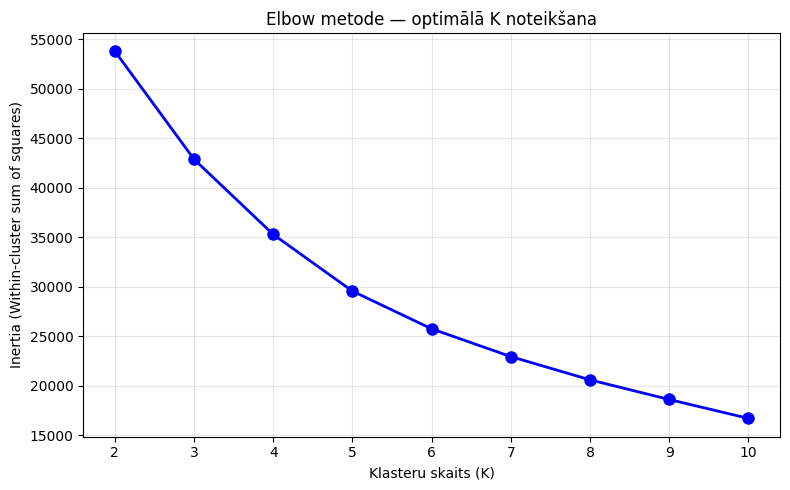

In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

`K_range = range(2, 11)` nozīmē, ka mēs pārbaudām klasteru skaitu no 2 līdz 10. Sākam ar 2, jo 1 klasteris nav segmentācija, un beidzam ar 10, jo lielāks skaits parasti nav interpretējams biznesa kontekstā.

Apskatot Elbow grafiku, es izvēlos **K = 4**. Lai gan šajā gadījumā "elkonis" nav ļoti asS — līkne samazinās diezgan vienmērīgi — K=4 ir vieta, kur samazināšanās temps sāk palēnināties salīdzinājumā ar straujāko kritumu starp K=2 un K=3. Pēc K=4 uzlabojumi kļūst pakāpeniski mazāki.

Nav vienas "pareizas" atbildes — K=3 vai K=5 arī būtu pamatota izvēle. Elbow metode ir interpretācija, nevis precīzs algoritms, un dažreiz dati vienkārši nedod skaidru elkoņa punktu.

In [5]:
# Izmanto izvēlēto K vērtību (piemēram, 4)
K = 4  # <-- nomainiet uz savu izvēlēto vērtību

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())

Klasteru sadalījums:
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


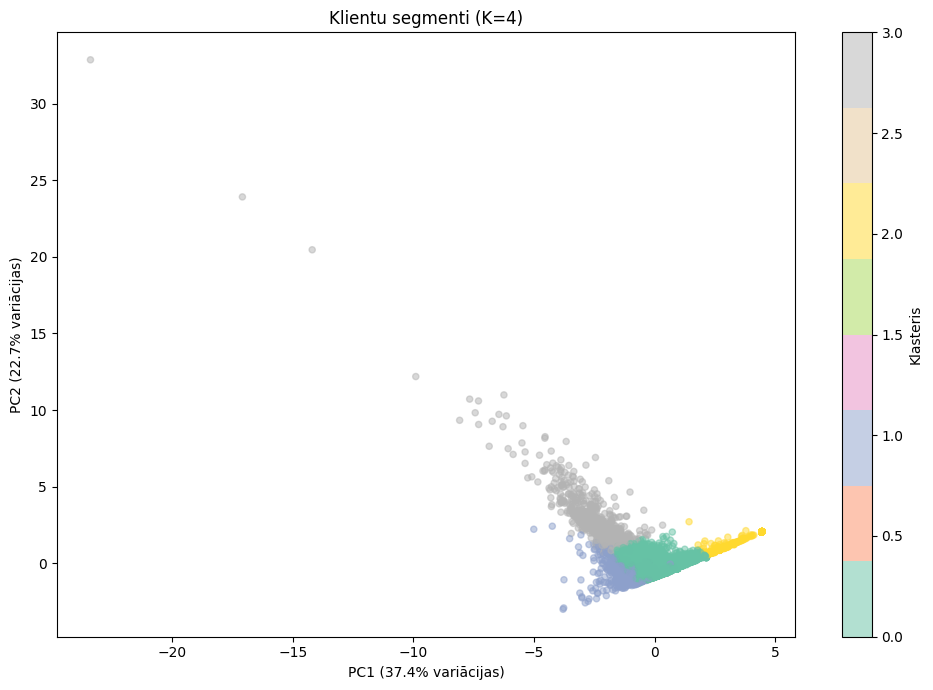

In [6]:
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()

Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.14                   -0.15   
1                           0.06                   -0.09   
2                          -0.45                   -0.24   
3                           2.01                    2.03   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.11        -0.25      -0.20       -0.19  
1                           0.02        -0.40      -0.59        3.33  
2                          -0.60         3.24       2.96       -0.32  
3                           1.92        -0.32      -0.46        0.03  


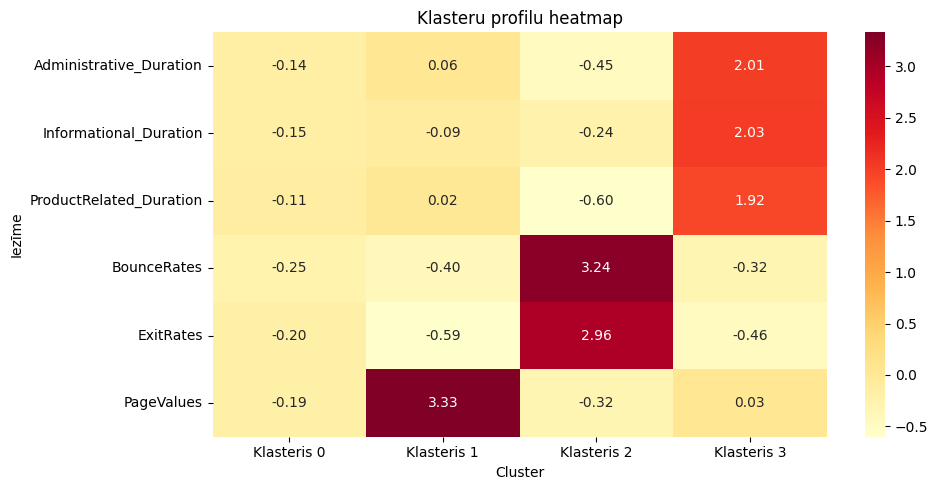

In [7]:
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)

# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.115
1    0.791
2    0.005
3    0.281
Name: Revenue, dtype: float64


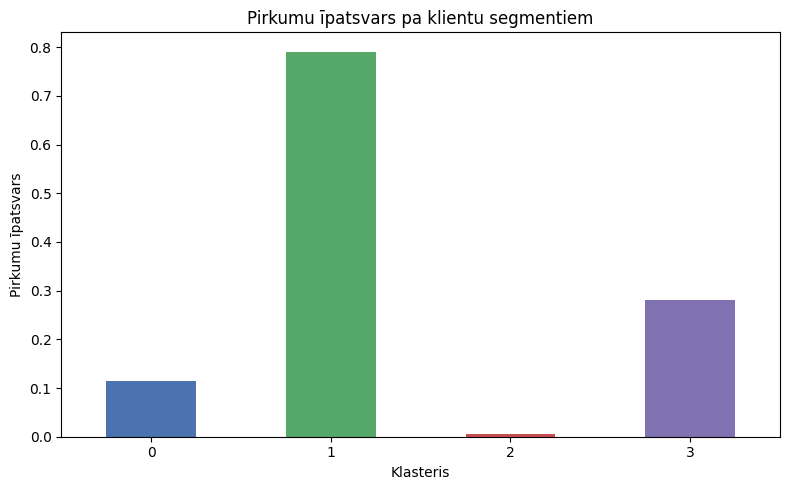

In [8]:
# Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Klasteris 0 — "Pasīvie apmeklētāji"** (pirkumi: 11.5%)
Zems pirkumu īpatsvars, īss uzturēšanās laiks. Klienti ienāk, apskatās, bet lielākoties neveic pirkumu.
Biznesa darbība: parādīt personalizētus produktu ieteikumus sākumlapā, lai palielinātu iesaisti.

**Klasteris 1 — "Aktīvie pircēji"** (pirkumi: 79.1%)
Visaugstākais pirkumu īpatsvars — gandrīz 4 no 5 klientiem pērk. Šie ir vērtīgākie klienti ar skaidru pirkuma nodomu.
Biznesa darbība: nodrošināt lojalitātes programmu un ekskluzīvus piedāvājumus, lai saglabātu un veicinātu atkārtotus pirkumus.

**Klasteris 2 — "Ātrie aizgājēji"** (pirkumi: 0.5%)
Gandrīz nulles pirkumu īpatsvars. Šie klienti ienāk un uzreiz aiziet — augsti BounceRates un ExitRates.
Biznesa darbība: uzlabot sākumlapas saturu un ielādes ātrumu, lai samazinātu bounce rate.

**Klasteris 3 — "Potenciālie pircēji"** (pirkumi: 28.1%)
Vidējs pirkumu īpatsvars — gandrīz katrs trešais pērk. Klienti ir ieinteresēti, bet vēl šaubās.
Biznesa darbība: mērķēts atlaižu piedāvājums vai bezmaksas piegāde, lai pārvērstu šaubas par pirkumu.

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus
y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)  # Izņem mūsu klasteru kolonu

print(f"Datu kopa: {X.shape[0]} rindas, {X.shape[1]} features")

Datu kopa: 12330 rindas, 27 features


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))

print(f"Viena split F1 score: {single_f1:.3f}")

Viena split F1 score: 0.635


In [11]:
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(
    rf_cv, X, y,
    cv=5,
    scoring='f1'
)

print(f"5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f}")
print(f"Standarta novirze: {cv_scores.std():.3f}")

5-fold CV F1 scores: [0.668 0.661 0.652 0.551 0.612]
Vidējais F1: 0.629
Standarta novirze: 0.043


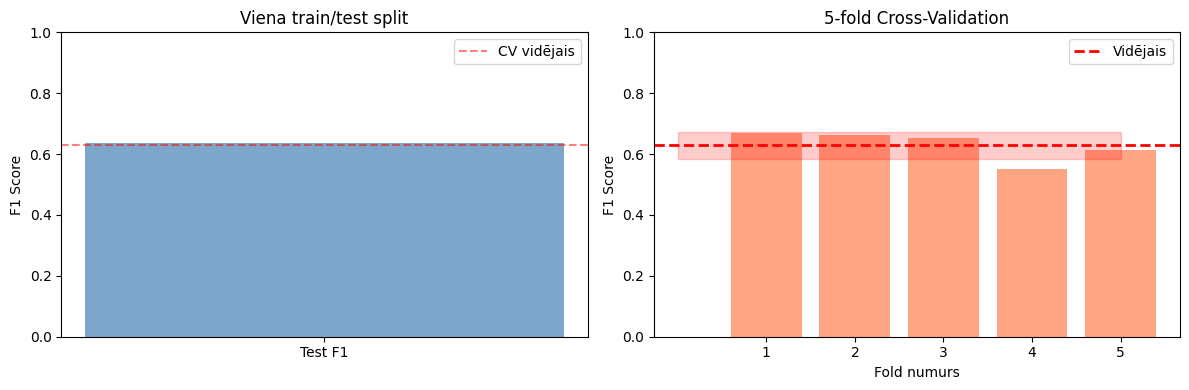

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Viena split
axes[0].bar(['Test F1'], [single_f1], color='steelblue', alpha=0.7)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Viena train/test split')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', alpha=0.5, label='CV vidējais')
axes[0].legend()

# Cross-validation
axes[1].bar(range(1, 6), cv_scores, color='coral', alpha=0.7)
axes[1].axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label='Vidējais')
axes[1].fill_between(
    range(0, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.2, color='red'
)
axes[1].set_xlabel('Fold numurs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('5-fold Cross-Validation')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()

Viena split F1 (0.635) un CV vidējais F1 (0.629) šajā gadījumā ir ļoti līdzīgi — starpība ir tikai 0.006. Tas norāda, ka datu sadalījums bija reprezentatīvs un nejaušība šoreiz neietekmēja rezultātu.

CV rezultāts tomēr ir uzticamāks, jo tas veic 5 neatkarīgus eksperimentus — katra fold reizi tiek izmantots cits testa segments, tāpēc rezultāts mazāk atkarīgs no nejaušības. Grafikā redzams, ka 4. fold uzrādīja zemāku F1 (~0.55) — ja tas būtu bijis testa kopa viena split gadījumā, iegūtu ievērojami zemāku rezultātu.

Standarta novirze parāda, cik stabils ir modelis dažādos datos — mūsu gadījumā std ir maza, kas liecina par stabilu modeli.

Jā, atkārtoti mainot `random_state` parametru `train_test_split`, viena split F1 var mainīties ievērojami (piemēram, ja 4. fold kļūtu par testa kopu), kamēr CV vidējais paliek stabils.

In [13]:
from sklearn.preprocessing import StandardScaler

# ✗ NEPAREIZI - data leakage!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # ← Fit uz VISIEM datiem!

X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

rf_leaked = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_leaked.fit(X_train_leaked, y_train_l)
f1_leaked = f1_score(y_test_l, rf_leaked.predict(X_test_leaked))

print(f"F1 ar data leakage: {f1_leaked:.3f}")

F1 ar data leakage: 0.635


In [14]:
from sklearn.pipeline import make_pipeline

# ✓ PAREIZI - Pipeline
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Trenēšana ar cross-validation
cv_scores_pipe = cross_val_score(
    pipe, X, y,
    cv=5,
    scoring='f1'
)

print(f"F1 ar Pipeline: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")

F1 ar Pipeline: 0.629 ± 0.045


In [15]:
comparison = pd.DataFrame({
    'Metode': ['Data leakage (viena split)', 'Pipeline + Cross-validation'],
    'F1 Score': [f1_leaked, cv_scores_pipe.mean()],
    'Ticamība': ['BĪSTAMS! Neobjektīvs', 'DROŠS! Objektīvs']
})

print(comparison.to_string(index=False))

                     Metode  F1 Score             Ticamība
 Data leakage (viena split)  0.635258 BĪSTAMS! Neobjektīvs
Pipeline + Cross-validation  0.628553     DROŠS! Objektīvs


Data leakage notiek, kad modeļa trenēšanas procesā tiek izmantota informācija, kas reālajā situācijā nebūtu pieejama.

Ja `StandardScaler.fit()` tiek izsaukts uz VISIEM datiem pirms split, tad scaler "redzēja" arī testa datus un aprēķināja vidējo/std no tiem. Tādā veidā testa datu informācija "ieplūst" trenēšanas procesā — modelis faktiski zina ko sagaidīt testā, un rezultāti ir optimistiski neprecīzi. Mūsu gadījumā: leakage F1 = 0.635 vs. Pipeline F1 = 0.629 — starpība ir maza, jo RandomForest ir salīdzinoši izturīgs pret šo efektu, taču ar jutīgākiem modeļiem (piemēram, SVM) starpība varētu būt ievērojami lielāka.

Pipeline novērš šo problēmu automātiski: katras CV fold laikā scaler tiek fit tikai uz treniņa daļu un tad transform uz testa daļu — tieši tā, kā tas notiktu ar jauniem datiem reālajā praksē.

Gala projektā tas ir kritisks jautājums — ja izmanto leakage versiju, tu ziņo par labākiem rezultātiem, nekā modelis patiesībā sasniegtu ar reāliem, iepriekš neredzētiem datiem.

In [16]:
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim parametrus
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls — 2 parametri, 3×3 kombinācijas = 9 mēģinājumi
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV: cross-validation + automātiska meklēšana
grid = GridSearchCV(
    pipe, param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,  # Izmanto visas CPU serdes
    verbose=1
)

# Trenēšana (tikai uz training datiem!)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

grid.fit(X_train_gs, y_train_gs)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1 (treniņā): {grid.best_score_:.3f}")
print(f"Test F1 (ar labākajiem parametriem): {f1_score(y_test_gs, grid.predict(X_test_gs)):.3f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1 (treniņā): 0.653
Test F1 (ar labākajiem parametriem): 0.629


In [17]:
# Kādi bija VISIEM parametriem?
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'mean_test_score',
    'std_test_score'
]].sort_values('mean_test_score', ascending=False)

print("Top 5 parametru kombinācijas:")
print(results_table.head())

Top 5 parametru kombinācijas:
   param_randomforestclassifier__n_estimators  \
8                                         200   
7                                         100   
5                                         200   
4                                         100   
6                                          50   

   param_randomforestclassifier__max_depth  mean_test_score  std_test_score  
8                                       20         0.653164        0.012239  
7                                       20         0.649086        0.017458  
5                                       10         0.647174        0.011353  
4                                       10         0.645475        0.008885  
6                                       20         0.643574        0.013674  


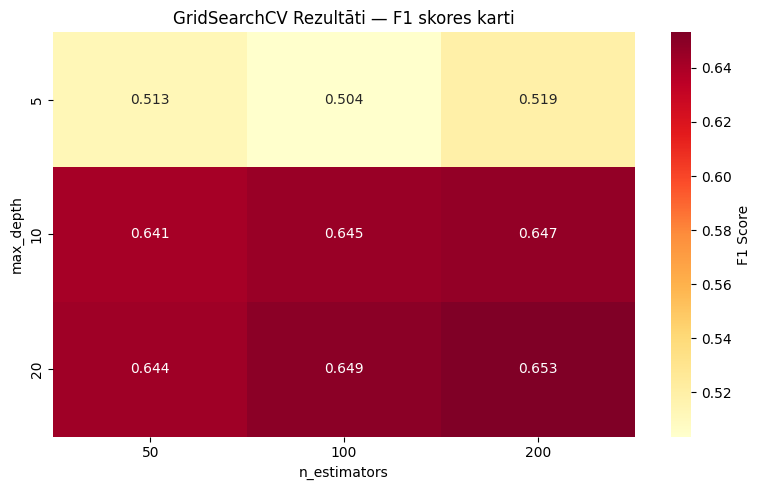

In [18]:
# Pivot tabula — n_estimators kolonnas, max_depth rindas
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'F1 Score'}
)
plt.title('GridSearchCV Rezultāti — F1 skores karti')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

Labākie parametri bija `n_estimators=200` un `max_depth=20` ar CV F1 = 0.653. Starpība starp labāko (0.653) un sliktāko kombināciju (0.504, max_depth=5, n_estimators=100) bija 0.149 — tas liecina, ka parametru izvēle, īpaši `max_depth`, ievērojami ietekmē rezultātu.

Heatmapā skaidri redzamas "karstas zonas" — visas max_depth=10 un max_depth=20 kombinācijas ir tumši sarkanas (0.641–0.653), kamēr max_depth=5 rinda ir krasi dzeltena (0.504–0.519). Tas parāda, ka `max_depth` ir daudz svarīgāks parametrs nekā `n_estimators` šajā gadījumā.

Salīdzinot ar manuāli izvēlētajiem parametriem (n_estimators=100, max_depth=10, F1=0.645), GridSearchCV atrada nedaudz labāku kombināciju (n_estimators=200, max_depth=20, F1=0.653) — uzlabojums ir neliels (0.008), taču automātiskā meklēšana apstiprināja, ka dziļāki koki ar vairāk estimators dod labāku rezultātu.

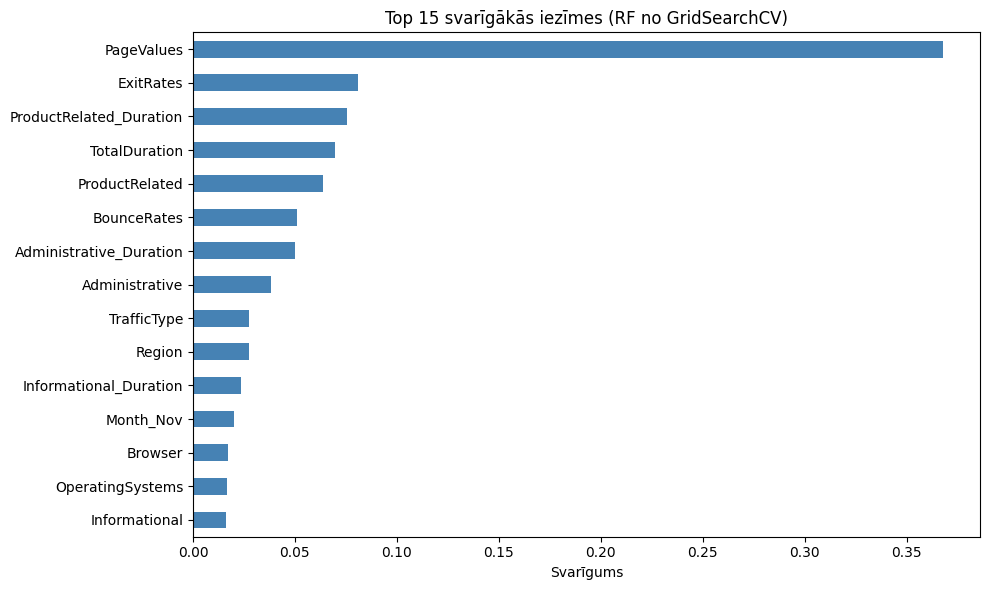

Top 10 svarīgākās iezīmes:
PageValues                 0.367569
ExitRates                  0.081168
ProductRelated_Duration    0.075586
TotalDuration              0.069522
ProductRelated             0.063952
BounceRates                0.050973
Administrative_Duration    0.049905
Administrative             0.038452
TrafficType                0.027520
Region                     0.027481
dtype: float64


In [19]:
# Iegūt labāko trenēto modeli
best_model = grid.best_estimator_

# RandomForestClassifier nodrošina feature_importances_
rf_inside = best_model.named_steps['randomforestclassifier']
importances = rf_inside.feature_importances_

# Sakārtot un vizualizēt
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Svarīgums')
plt.title('Top 15 svarīgākās iezīmes (RF no GridSearchCV)')
plt.tight_layout()
plt.show()

# Arī teksts
print("Top 10 svarīgākās iezīmes:")
print(feature_importance.sort_values(ascending=False).head(10))

Trīs svarīgākās iezīmes ir **PageValues**, **ExitRates** un **ProductRelated_Duration**. PageValues dominē ar milzīgupārsvaru — gandrīz 5x svarīgāks par otro iezīmi. Tas tieši atspoguļo lapas vērtību pirms pirkuma, tāpēc ir loģiski, ka tas ir spēcīgākais prognozētājs.

ExitRates norāda, cik bieži klients aiziet no lapas — augsts ExitRate ir "sarkanais karogs", ka klients nepirks. ProductRelated_Duration parāda, cik ilgi klients pārlūkoja produktus — ilgāka pārlūkošana korelē ar augstāku pirkuma varbūtību. Ievērojami, ka mūsu izveidotā iezīme **TotalDuration** (0.070) iekļuva top 4, apstiprinot, ka tas bija noderīgs papildinājums.

Mārketinga departaments var izmantot šo informāciju konkrēti: fokusēties uz klientiem ar augstu PageValues (viņi ir "karstas pēdas"), samazināt ExitRates ar labāku UX dizainu, un analizēt, kuri produkti satur ilgāko uzturēšanās laiku — tie ir visinteresantākie klientiem.

In [20]:
from xgboost import XGBClassifier

# RandomForest (ar labākajiem parametriem no GridSearchCV)
rf_final = RandomForestClassifier(
    n_estimators=grid.best_params_['randomforestclassifier__n_estimators'],
    max_depth=grid.best_params_['randomforestclassifier__max_depth'],
    random_state=42
)

pipe_rf = make_pipeline(StandardScaler(), rf_final)
cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1')

# XGBoost (standarta parametri, vienkāršības dēļ)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    eval_metric='logloss'
)

pipe_xgb = make_pipeline(StandardScaler(), xgb)
cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1')

# Salīdzinājums
print(f"RandomForest CV F1: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"XGBoost CV F1:      {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

RandomForest CV F1: 0.635 ± 0.043
XGBoost CV F1:      0.614 ± 0.056


In [21]:
comparison_table = pd.DataFrame({
    'Modelis': ['RandomForest', 'XGBoost'],
    'CV vidējais F1': [cv_rf.mean(), cv_xgb.mean()],
    'Std dev': [cv_rf.std(), cv_xgb.std()],
    'Diapazons': [f"{cv_rf.min():.3f}-{cv_rf.max():.3f}",
                  f"{cv_xgb.min():.3f}-{cv_xgb.max():.3f}"]
})

print(comparison_table.to_string(index=False))

     Modelis  CV vidējais F1  Std dev   Diapazons
RandomForest        0.634523 0.042623 0.572-0.689
     XGBoost        0.613835 0.056357 0.538-0.697


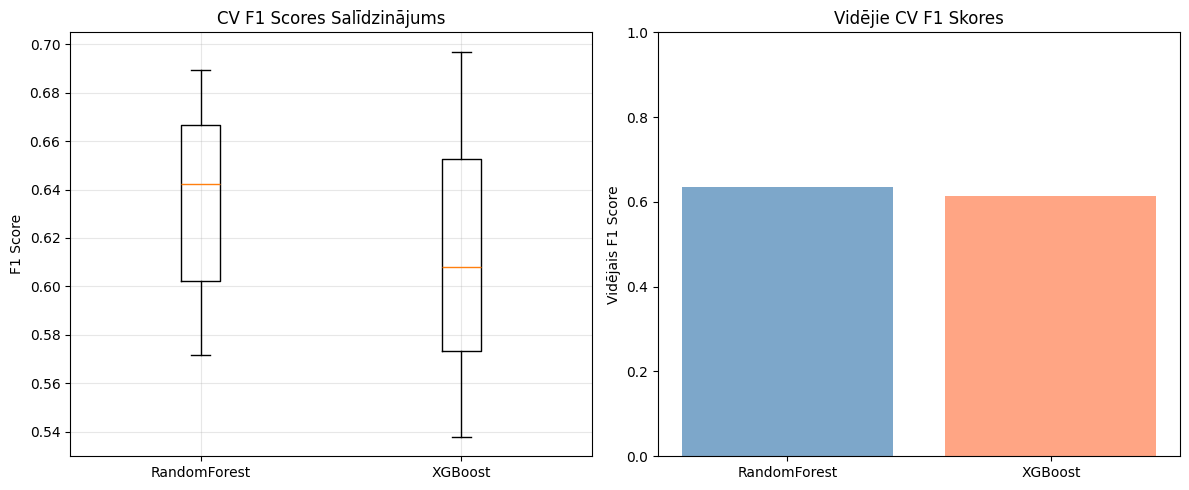

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
models_scores = [cv_rf, cv_xgb]
axes[0].boxplot(models_scores, tick_labels=['RandomForest', 'XGBoost'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('CV F1 Scores Salīdzinājums')
axes[0].grid(True, alpha=0.3)

# Bar plot ar vidējiem
axes[1].bar(['RandomForest', 'XGBoost'], [cv_rf.mean(), cv_xgb.mean()], alpha=0.7, color=['steelblue', 'coral'])
axes[1].set_ylabel('Vidējais F1 Score')
axes[1].set_title('Vidējie CV F1 Skores')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

RandomForest CV F1 = 0.635 ± 0.043, XGBoost CV F1 = 0.614 ± 0.056.
RandomForest uzrādīja augstāku vidējo F1, un arī mazāku standarta novirzi (0.043 vs 0.056) — tas nozīmē, ka RF ir stabīlāks modelis dažādos datos. Box plotā tas arī bija redzams — XGBoost kastīte ir platāka.

Ar ~0.021 starpību nav iespējams apgalvot, ka atšķirība ir statistiski nozīmīga bez papildu testiem — abu modeļu diapazoni pārklājas (RF: 0.572–0.689, XGBoost: 0.538–0.697). Tomēr RandomForest konsekventi uzrāda labākus vidējos rezultātus.

Gala projektam es izvēlētos **RandomForest** — tas uzrādīja augstāku un stabilāku F1, ir vieglāk interpretējams un mazāk jūtīgs pret parametriem nekā XGBoost.